In [ ]:
import pandas as pd
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns
import os

In [32]:
data_dir = 'gbfs_in_files'
station_status =pd.read_csv(os.path.join(data_dir, 'A1-station_status.csv')) 
station_info = pd.read_csv(os.path.join(data_dir, 'station_info_all_2026-06-05.csv'))

## Exploratory Data Analysis

In [33]:
station_info.head(3)

,station_id,external_id,name,physical_configuration,lat,lon,altitude,address,cross_street,post_code,...,rental_methods,is_virtual_station,groups,nearby_distance,_bluetooth_id,_ride_code_support,rental_uris,obcn,short_name,is_valet_station
0,1,eb1564d9-df87-11ef-b9d3-0681a956ccf1,001 - CL 82 con KR 11,REGULAR,4.665803,-74.052844,NaN,Calle 82 entre Carrera 11 y Carrera 12,EL RETIRO,1111,...,"['key', 'transitcard', 'creditcard', 'phone']",False,[],1000,f971,True,{},NaN,NaN,NaN
1,2,eb156c20-df87-11ef-b9d3-0681a956ccf1,002 - CL 65 con KR 10,REGULAR,4.650789,-74.061453,NaN,Calle 65 entre Carrera 10 y Carrera 11,CHAPINERO NORTE,1111,...,"['key', 'transitcard', 'creditcard', 'phone']",False,[],1000,fdc2,True,{},NaN,NaN,NaN
2,4,eb157396-df87-11ef-b9d3-0681a956ccf1,004 - Parque de Japón,REGULAR,4.669821,-74.050483,NaN,Calle 86a entre Carrera 11 y Carrera 11a,LA CABRERA,1111,...,"['key', 'transitcard', 'creditcard', 'phone']",False,[],1000,d65f,True,{},NaN,NaN,NaN


In [34]:
station_status.head()

,station_id,status_uuid,num_bikes_available,num_bikes_disabled,num_docks_available,num_docks_disabled,last_reported,city,last_reported_local_date
0,41,9c92e04f-b8be-4c46-a131-7c346f0a0fbe,4,6,50,0,1731382546,bogota_co,2024-11-11 22:35:46
1,46,7320e61b-9da9-434d-9b23-79d4ac0975a0,19,3,12,0,1731382581,bogota_co,2024-11-11 22:36:21
2,25,02c131d8-d4e5-493e-a394-6793cf8bd078,1,1,25,0,1731382585,bogota_co,2024-11-11 22:36:25
3,5,5de1cebc-4214-4d46-86f9-5e5c42e1b129,20,3,15,1,1731382629,bogota_co,2024-11-11 22:37:09
4,5,b467fd79-400f-4c6a-9207-e52c9d0b0309,5,0,33,1,1731999279,bogota_co,2024-11-19 01:54:39


In [35]:
## register last_reported_local_date as datetime dtype

## use timestamp in last_reported to create datetime column last_reported_local_date with local timezone Bogota
station_status['last_reported_local_date'] = pd.to_datetime(station_status['last_reported'], unit='s', utc=True)  
station_status['last_reported_local_date'] = station_status['last_reported_local_date'].dt.tz_convert('America/Bogota')	
station_status.head()

,station_id,status_uuid,num_bikes_available,num_bikes_disabled,num_docks_available,num_docks_disabled,last_reported,city,last_reported_local_date
0,41,9c92e04f-b8be-4c46-a131-7c346f0a0fbe,4,6,50,0,1731382546,bogota_co,2024-11-11 22:35:46-05:00
1,46,7320e61b-9da9-434d-9b23-79d4ac0975a0,19,3,12,0,1731382581,bogota_co,2024-11-11 22:36:21-05:00
2,25,02c131d8-d4e5-493e-a394-6793cf8bd078,1,1,25,0,1731382585,bogota_co,2024-11-11 22:36:25-05:00
3,5,5de1cebc-4214-4d46-86f9-5e5c42e1b129,20,3,15,1,1731382629,bogota_co,2024-11-11 22:37:09-05:00
4,5,b467fd79-400f-4c6a-9207-e52c9d0b0309,5,0,33,1,1731999279,bogota_co,2024-11-19 01:54:39-05:00


<Axes: title={'center': 'Station Status: Number of Bikes Available vs. Last Reported Local Date'}, xlabel='Last Reported Local Date', ylabel='Number of Bikes Available'>

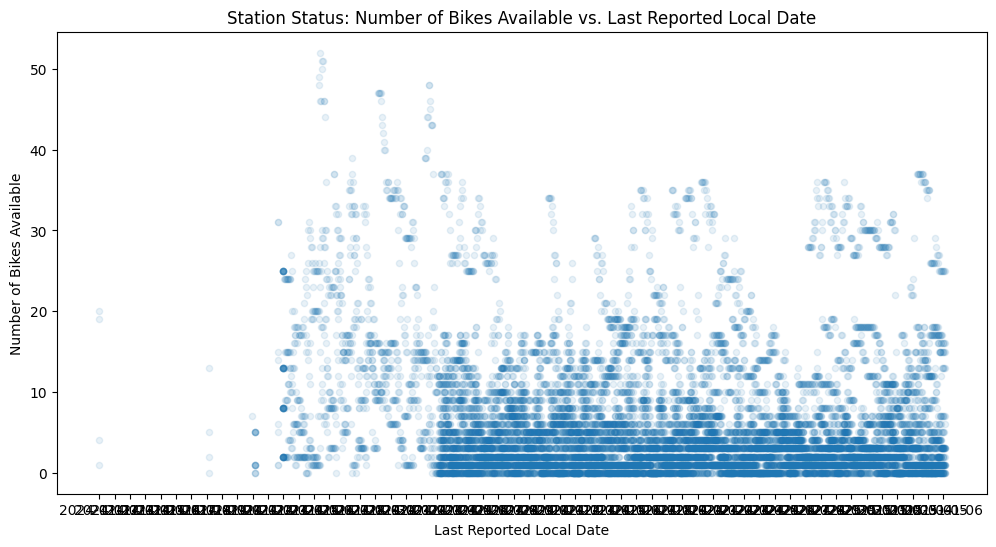

In [36]:
# vertical labels for x axis
station_status.plot(
  	x='last_reported_local_date', y='num_bikes_available', 
  	kind='scatter', alpha=0.1, figsize=(12, 6),  
  	title='Station Status: Number of Bikes Available vs. Last Reported Local Date', 
  	xlabel='Last Reported Local Date', ylabel='Number of Bikes Available',
  	xticks=pd.date_range(start=station_status['last_reported_local_date'].min(), end=station_status['last_reported_local_date'].max(), freq='D')) 

<Axes: title={'center': 'Station Status: Number of Bikes Available vs. Last Reported Local Date'}, xlabel='Last Reported Local Date', ylabel='Number of Bikes Available'>

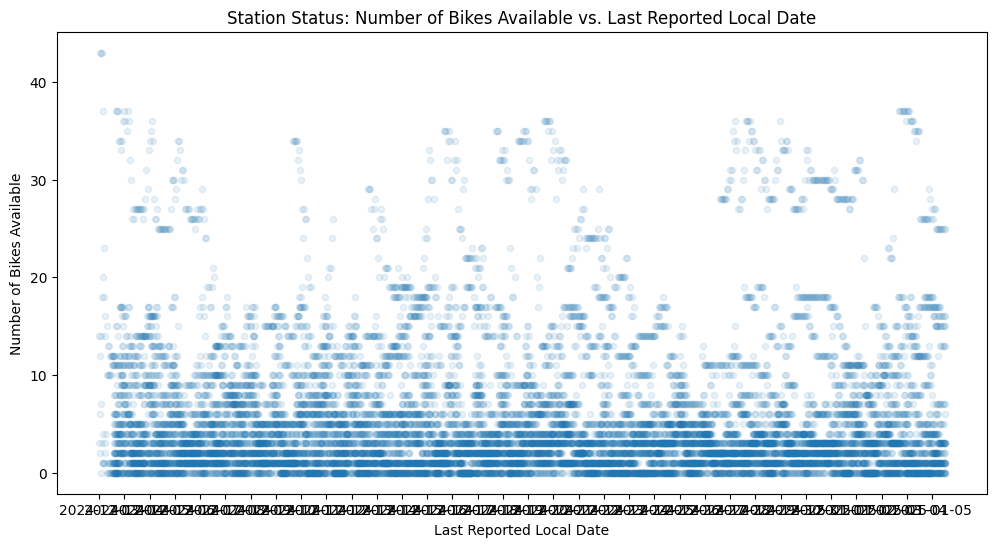

In [37]:
station_status = station_status[1000:]
station_status.plot(
  	x='last_reported_local_date', y='num_bikes_available', 
  	kind='scatter', alpha=0.1, figsize=(12, 6),  
  	title='Station Status: Number of Bikes Available vs. Last Reported Local Date', 
  	xlabel='Last Reported Local Date', ylabel='Number of Bikes Available',
  	xticks=pd.date_range(start=station_status['last_reported_local_date'].min(), end=station_status['last_reported_local_date'].max(), freq='D')) 

In [43]:
station_status_capacity = station_status.merge(station_info[['station_id', 'capacity']], on='station_id', how='left')
station_status_capacity['capacity'] = station_status_capacity['capacity'].fillna(0)
station_status_capacity

,station_id,status_uuid,num_bikes_available,num_bikes_disabled,num_docks_available,num_docks_disabled,last_reported,city,last_reported_local_date,capacity
0,46,6bc27482-3849-40ac-ab3e-9cf9abc2d5ef,3,1,30,0,1733247360,bogota_co,2024-12-03 12:36:00-05:00,31.0
1,5,017ecb34-a6cd-460e-899f-cb61cbeeb1ae,14,1,23,0,1733247375,bogota_co,2024-12-03 12:36:15-05:00,39.0
2,5,144eb201-8a22-4251-a9a2-bec668f5dee3,12,1,25,0,1733250839,bogota_co,2024-12-03 13:33:59-05:00,39.0
3,41,4b3beab4-4c56-4892-9aae-da516e59b2fb,43,2,15,0,1733250855,bogota_co,2024-12-03 13:34:15-05:00,55.0
4,25,ccc08444-d363-425f-8da6-a0bd837f775d,6,3,18,0,1733250935,bogota_co,2024-12-03 13:35:35-05:00,27.0
...,...,...,...,...,...,...,...,...,...,...
14692,15,4656236c-7f9a-499d-b15a-20cb6c070e2b,0,0,11,0,1736141779,bogota_co,2025-01-06 00:36:19-05:00,11.0
14693,17,9a6519cd-931c-4c53-ab1d-8fd0c3c02b97,7,0,4,0,1736141783,bogota_co,2025-01-06 00:36:23-05:00,11.0
14694,11,6ef9c9a7-29fd-4449-9a1e-3901a9a0828c,15,0,4,0,1736141793,bogota_co,2025-01-06 00:36:33-05:00,19.0
14695,10,cb9c7cb9-ad6e-4f58-b55d-737c468b6fdc,1,1,9,0,1736141799,bogota_co,2025-01-06 00:36:39-05:00,11.0


<Axes: title={'center': 'Station Status: Number of Bikes Available vs. Last Reported Local Date for Station 17'}, xlabel='Last Reported Local Date', ylabel='Number of Bikes Available'>

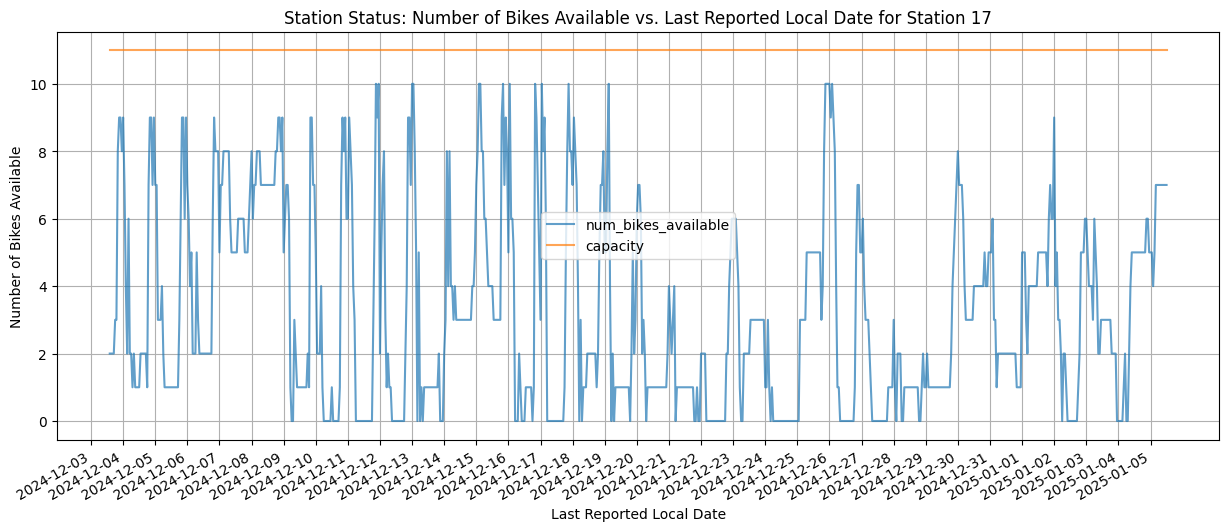

In [57]:
station_status_capacity[station_status_capacity['station_id']==17].plot(
  	x='last_reported_local_date', y=['num_bikes_available','capacity'],
  	kind='line', alpha=0.7, figsize=(15, 6),
  	title='Station Status: Number of Bikes Available vs. Last Reported Local Date for Station 17',
  	xlabel='Last Reported Local Date', ylabel='Number of Bikes Available',
  	xticks=pd.date_range(start=station_status_capacity['last_reported_local_date'].min(), end=station_status_capacity['last_reported_local_date'].max(), freq='D'), grid=True)	

In [53]:
station_status_capacity['perc_bikes_available'] = station_status_capacity['num_bikes_available'] / station_status_capacity['capacity']
station_status_capacity['perc_bikes_disabled'] = station_status_capacity['num_bikes_disabled'] / station_status_capacity['capacity']
station_status_capacity.head(3)

,station_id,status_uuid,num_bikes_available,num_bikes_disabled,num_docks_available,num_docks_disabled,last_reported,city,last_reported_local_date,capacity,perc_bikes_available,perc_bikes_disabled
0,46,6bc27482-3849-40ac-ab3e-9cf9abc2d5ef,3,1,30,0,1733247360,bogota_co,2024-12-03 12:36:00-05:00,31.0,0.096774,0.032258
1,5,017ecb34-a6cd-460e-899f-cb61cbeeb1ae,14,1,23,0,1733247375,bogota_co,2024-12-03 12:36:15-05:00,39.0,0.358974,0.025641
2,5,144eb201-8a22-4251-a9a2-bec668f5dee3,12,1,25,0,1733250839,bogota_co,2024-12-03 13:33:59-05:00,39.0,0.307692,0.025641


<Axes: title={'center': 'Station Status: Percentage of Bikes Available and Disabled vs. Last Reported Local Date'}, xlabel='Last Reported Local Date', ylabel='Percentage of Bikes\t Available and Disabled'>

/Users/admin/Library/Mobile Documents/com~apple~CloudDocs/Coding/Smart Cities - Rename History/smart-cities-open-data/venv/lib/python3.13/site-packages/IPython/core/events.py:96: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/admin/Library/Mobile Documents/com~apple~CloudDocs/Coding/Smart Cities - Rename History/smart-cities-open-data/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


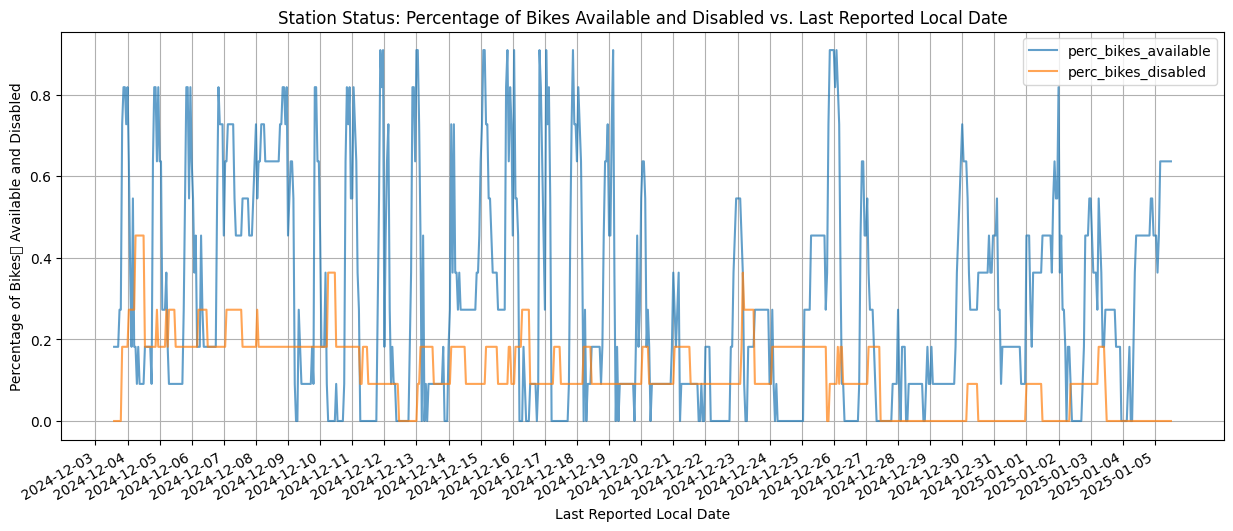

In [58]:
## same plot but with percentage of bikes available and percentage of bikes disabled
station_status_capacity[station_status_capacity['station_id']==17].plot(
  	x='last_reported_local_date', y=['perc_bikes_available', 'perc_bikes_disabled'], 
  	kind='line', alpha=0.7, figsize=(15, 6),  
  	title='Station Status: Percentage of Bikes Available and Disabled vs. Last Reported Local Date', 
  	xlabel='Last Reported Local Date', ylabel='Percentage of Bikes	 Available and Disabled',
  	xticks=pd.date_range(start=station_status_capacity['last_reported_local_date'].min(), end=station_status_capacity['last_reported_local_date'].max(), freq='D'), grid=True)

In [71]:
## groupby hour and get mean hourly perc_bikes_available
station_status_capacity['hour'] = station_status_capacity['last_reported_local_date'].dt.hour
hourly_bikes_available = station_status_capacity.groupby('hour')['num_bikes_available'].mean()
hourly_bikes_available.head()

hour
0    4.144026
1    4.133779
2    4.124183
3    4.220096
4    4.504918
Name: num_bikes_available, dtype: float64

<Axes: title={'center': 'Average Number of Bikes Available by Hour of Day'}, xlabel='Hour of Day', ylabel='Average Number of Bikes Available'>

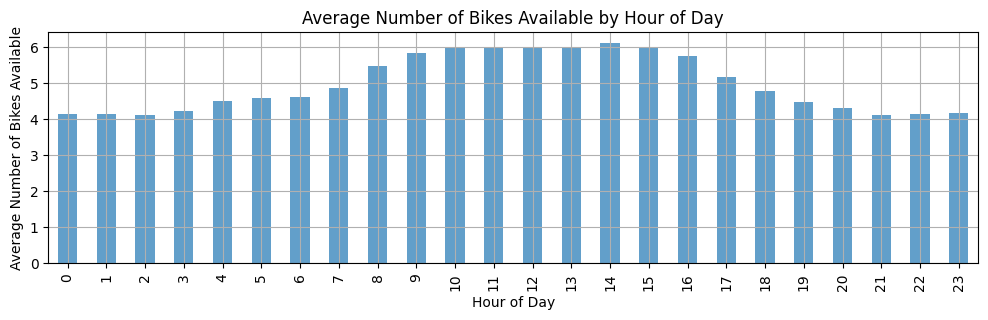

In [69]:
#plot hourly bikes available
hourly_bikes_available.plot(
  	kind='bar', alpha=0.7, figsize=(12, 3),
  	title='Average Number of Bikes Available by Hour of Day',
  	xlabel='Hour of Day', ylabel='Average Number of Bikes Available',
  	grid=True)		

<Axes: title={'center': 'Average Number of Bikes Disabled by Hour of Day'}, xlabel='Hour of Day', ylabel='Average Number of Bikes Disabled'>

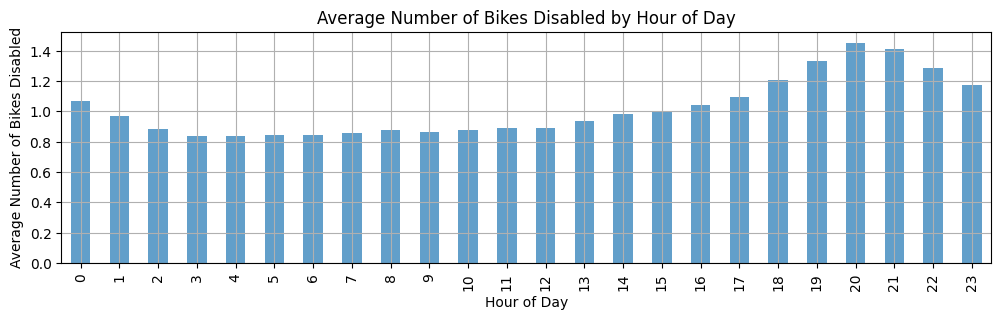

In [73]:
## plot hourly bikes disabled 
hourly_bikes_disabled = station_status_capacity.groupby('hour')['num_bikes_disabled'].mean()
hourly_bikes_disabled.plot(
  	kind='bar', alpha=0.7, figsize=(12, 3),
  	title='Average Number of Bikes Disabled by Hour of Day',
  	xlabel='Hour of Day', ylabel='Average Number of Bikes Disabled',
  	grid=True)